## Bussiness Question


1.   Kategori produk skincare apa yang paling dominan dalam dataset?
2.   Jenis kulit apa yang paling banyak didukung oleh produk dalam dataset?
3.   Bagaimana karakteristik harga produk skincare dalam dataset?
4.   Kategori produk skincare mana yang memiliki rata-rata harga tertinggi?
5.   Bagaimana distribusi rating produk skincare dalam dataset?



## Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cosmetics.csv")

In [3]:
df.head()

,Label,Brand,Name,Price,Rank,Ingredients,Combination,Dry,Normal,Oily,Sensitive
0,Moisturizer,LA MER,Crème de la Mer,175,4.1,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",1,1,1,1,1
1,Moisturizer,SK-II,Facial Treatment Essence,179,4.1,"Galactomyces Ferment Filtrate (Pitera), Butyle...",1,1,1,1,1
2,Moisturizer,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",1,1,1,1,0
3,Moisturizer,LA MER,The Moisturizing Soft Cream,175,3.8,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",1,1,1,1,1
4,Moisturizer,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,"Water, Snail Secretion Filtrate, Phenyl Trimet...",1,1,1,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472 entries, 0 to 1471
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Label        1472 non-null   object 
 1   Brand        1472 non-null   object 
 2   Name         1472 non-null   object 
 3   Price        1472 non-null   int64  
 4   Rank         1472 non-null   float64
 5   Ingredients  1472 non-null   object 
 6   Combination  1472 non-null   int64  
 7   Dry          1472 non-null   int64  
 8   Normal       1472 non-null   int64  
 9   Oily         1472 non-null   int64  
 10  Sensitive    1472 non-null   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 126.6+ KB


In [5]:
df.describe()

,Price,Rank,Combination,Dry,Normal,Oily,Sensitive
count,1472.000000,1472.000000,1472.00000,1472.000000,1472.000000,1472.000000,1472.000000
mean,55.584239,4.153261,0.65625,0.614130,0.652174,0.607337,0.513587
std,45.014429,0.633918,0.47512,0.486965,0.476442,0.488509,0.499985
min,3.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,4.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,42.500000,4.300000,1.00000,1.000000,1.000000,1.000000,1.000000
75%,68.000000,4.500000,1.00000,1.000000,1.000000,1.000000,1.000000
max,370.000000,5.000000,1.00000,1.000000,1.000000,1.000000,1.000000


## Data Cleaning

In [6]:
df.isnull().sum()

,0
Label,0
Brand,0
Name,0
Price,0
Rank,0
Ingredients,0
Combination,0
Dry,0
Normal,0
Oily,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
print("Dataset tidak memiliki missing value maupun data duplikat.")

Dataset tidak memiliki missing value maupun data duplikat.


**Exploratory Data Analysis (EDA)**

*   Distribusi Kategori Produk

Tujuan analisis ini adalah mengetahui kategori produk skincare yang paling dominan dalam dataset.

Kategori produk skincare apa yang paling dominan dalam dataset?


In [9]:
df["Label"].value_counts()

,count
Label,
Moisturizer,298
Cleanser,281
Face Mask,266
Treatment,248
Eye cream,209
Sun protect,170


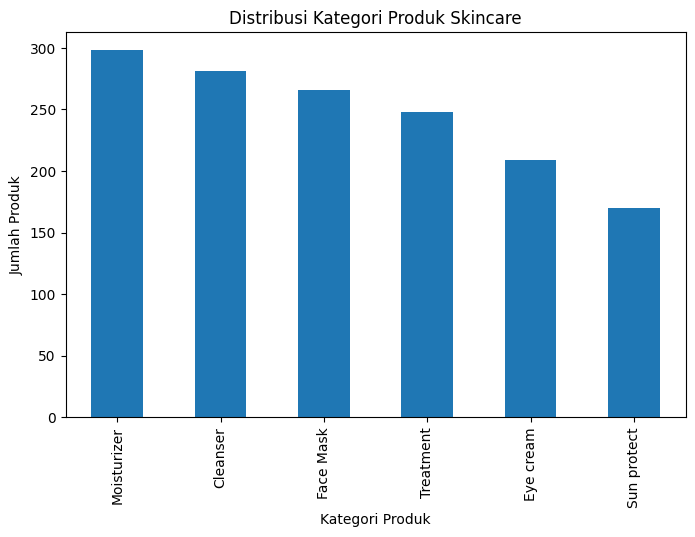

In [10]:
import matplotlib.pyplot as plt

label_counts = df["Label"].value_counts()

plt.figure(figsize=(8,5))
label_counts.plot(kind="bar")
plt.title("Distribusi Kategori Produk Skincare")
plt.xlabel("Kategori Produk")
plt.ylabel("Jumlah Produk")
plt.show()

### Insight

Kategori Moisturizer merupakan kategori produk dengan jumlah terbanyak (298 produk), sedangkan Sun Protect merupakan kategori dengan jumlah paling sedikit (170 produk).


*   Distribusi Jenis Kulit

Analisis ini bertujuan mengetahui jenis kulit yang paling banyak didukung oleh produk dalam dataset.




Jenis kulit apa yang paling banyak didukung oleh produk dalam dataset?


In [11]:
skin_counts = {
    "Combination": df["Combination"].sum(),
    "Dry": df["Dry"].sum(),
    "Normal": df["Normal"].sum(),
    "Oily": df["Oily"].sum(),
    "Sensitive": df["Sensitive"].sum()
}

skin_counts

{'Combination': np.int64(966),
 'Dry': np.int64(904),
 'Normal': np.int64(960),
 'Oily': np.int64(894),
 'Sensitive': np.int64(756)}

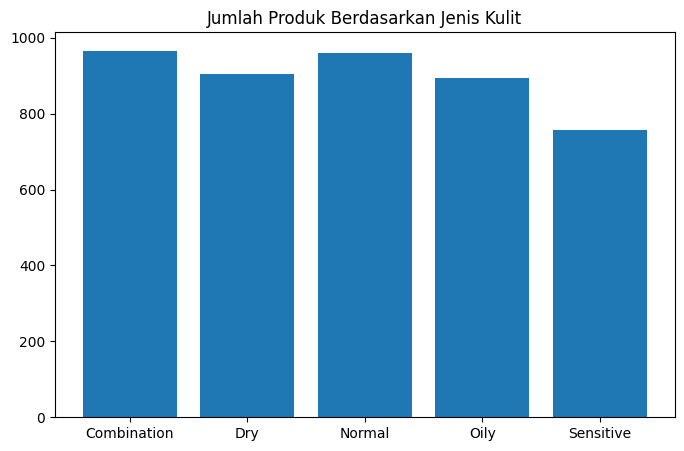

In [12]:
plt.figure(figsize=(8,5))
plt.bar(skin_counts.keys(), skin_counts.values())
plt.title("Jumlah Produk Berdasarkan Jenis Kulit")
plt.show()

### Insight

Produk untuk kulit kombinasi memiliki jumlah paling banyak (966 produk), sedangkan produk untuk kulit sensitif memiliki jumlah paling sedikit (756 produk).



*   Analisis Harga




In [13]:
print("Harga rata-rata :", round(df["Price"].mean(),2))
print("Harga minimum :", df["Price"].min())
print("Harga maksimum :", df["Price"].max())

Harga rata-rata : 55.58
Harga minimum : 3
Harga maksimum : 370


### Insight

Harga rata-rata produk skincare dalam dataset adalah 55.58 dengan rentang harga dari 3 hingga 370.



*   Harga Rata - rata per Kategori




Bagaimana karakteristik harga produk skincare dalam dataset?


In [14]:
df.groupby("Label")["Price"].mean().sort_values(ascending=False)

,Price
Label,
Treatment,79.177419
Moisturizer,69.087248
Eye cream,63.602871
Sun protect,45.905882
Face Mask,42.624060
Cleanser,32.601423


### Insight

Kategori Treatment memiliki rata-rata harga tertinggi (79.18), sedangkan kategori Cleanser memiliki rata-rata harga terendah (32.60).



*   Analisis Rating Produk



Kategori produk skincare mana yang memiliki rata-rata harga tertinggi?


In [15]:
print("Rating rata-rata :", round(df["Rank"].mean(), 2))
print("Rating minimum   :", df["Rank"].min())
print("Rating maksimum  :", df["Rank"].max())

Rating rata-rata : 4.15
Rating minimum   : 0.0
Rating maksimum  : 5.0


## Insight
1. Mayoritas produk memiliki rating yang cukup tinggi

Rata-rata rating 4.15 dari 5 menunjukkan bahwa sebagian besar produk dalam dataset mendapatkan penilaian positif dari pengguna.

2. Ada produk dengan rating 0

Ini menarik dan perlu dicek lebih lanjut.

Rating 0 bisa berarti:

Produk belum memiliki review.
Data tidak tersedia lalu diisi 0.
Memang ada produk dengan penilaian sangat buruk.

Sebagai Data Scientist, jangan langsung menyimpulkan produk tersebut jelek.

3. Dataset mencakup produk dengan rentang rating lengkap

Dari 0 hingga 5, sehingga analisis kualitas produk masih memungkinkan dilakukan.

Bagaimana distribusi rating produk skincare dalam dataset?

In [16]:
df[df["Rank"] == 0][["Brand", "Name", "Rank"]].head(10)

,Brand,Name,Rank
97,LA MER,The Concentrate Mini,0.0
116,SK-II,Facial Treatment Essence Karan Singh Limited E...,0.0
279,CLINIQUE,Limited Edition Dramatically Different Moistur...,0.0
365,ESTÉE LAUDER,Nutritious Radiant Vitality Energy Lotion,0.0
389,FRESH,Rose Deep Hydration Toner Mini,0.0
452,MURAD,Clarifying Toner,0.0
531,KATE SOMERVILLE,Kate's Mini Must Haves,0.0
534,PHILOSOPHY,Purity Made Simple® Facial Cleansing Gel & Eye...,0.0
752,PETER THOMAS ROTH,AHA/BHA Acne Clearing Gel,0.0
864,GLAMGLOW,The Ultimate Glow Set,0.0


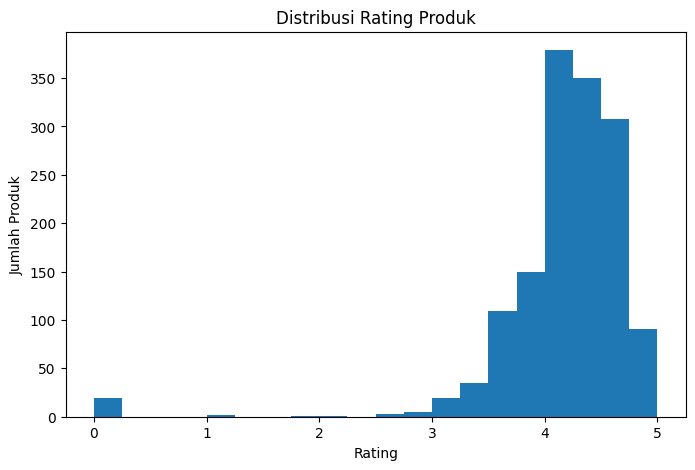

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Rank"], bins=20)

plt.title("Distribusi Rating Produk")
plt.xlabel("Rating")
plt.ylabel("Jumlah Produk")

plt.show()

In [18]:
df.duplicated().sum()

np.int64(0)

## Data Dictionary

| Kolom | Tipe Data | Deskripsi |
|---------|---------|---------|
| Label | String | Kategori produk skincare |
| Brand | String | Nama merek produk |
| Name | String | Nama produk skincare |
| Price | Integer | Harga produk |
| Rank | Float | Rating produk |
| Ingredients | String | Daftar kandungan produk |
| Combination | Integer | Kecocokan untuk kulit kombinasi (1 = cocok, 0 = tidak cocok) |
| Dry | Integer | Kecocokan untuk kulit kering (1 = cocok, 0 = tidak cocok) |
| Normal | Integer | Kecocokan untuk kulit normal (1 = cocok, 0 = tidak cocok) |
| Oily | Integer | Kecocokan untuk kulit berminyak (1 = cocok, 0 = tidak cocok) |
| Sensitive | Integer | Kecocokan untuk kulit sensitif (1 = cocok, 0 = tidak cocok) |

Kesimpulan

Berdasarkan hasil proses Data Understanding, Data Cleaning, dan Exploratory Data Analysis (EDA) terhadap dataset skincare yang terdiri dari 1.472 produk, diperoleh beberapa temuan penting.

1. Dataset terdiri dari enam kategori utama produk skincare, yaitu Moisturizer, Cleanser, Face Mask, Treatment, Eye Cream, dan Sun Protect. Kategori Moisturizer merupakan kategori dengan jumlah produk terbanyak sebanyak 298 produk, sedangkan Sun Protect merupakan kategori dengan jumlah produk paling sedikit sebanyak 170 produk.
2. Analisis jenis kulit menunjukkan bahwa produk untuk Combination Skin dan Normal Skin mendominasi dataset dengan masing-masing 966 dan 960 produk. Sementara itu, produk yang ditujukan untuk Sensitive Skin memiliki jumlah paling sedikit, yaitu 756 produk.
3. Berdasarkan analisis harga, rata-rata harga produk skincare dalam dataset adalah 55,58 dengan rentang harga mulai dari 3 hingga 370. Hal ini menunjukkan bahwa dataset mencakup berbagai segmen pasar, mulai dari produk terjangkau hingga produk premium.
4. Analisis rata-rata harga per kategori menunjukkan bahwa kategori Treatment memiliki rata-rata harga tertinggi sebesar 79,18, diikuti oleh Moisturizer sebesar 69,09. Sebaliknya, kategori Cleanser memiliki rata-rata harga terendah sebesar 32,60.
5. Hasil analisis rating menunjukkan bahwa rata-rata rating produk adalah 4,15 dari 5, yang mengindikasikan bahwa sebagian besar produk dalam dataset memperoleh penilaian positif dari pengguna. Distribusi rating juga menunjukkan bahwa mayoritas produk berada pada rentang rating tinggi (3,5–5,0).

Secara keseluruhan, hasil analisis menunjukkan bahwa dataset skincare memiliki kualitas data yang baik dan cukup representatif untuk digunakan dalam pengembangan sistem rekomendasi skincare pada proyek LumiSkin, khususnya dalam memberikan rekomendasi berdasarkan jenis kulit dan karakteristik produk skincare.